In [1]:
import pandas as pd

events = pd.read_csv("output/events.csv")

# Parse as timezone-aware in UTC, then convert to NY
events["timestamp_ny"] = pd.to_datetime(events["timestamp_ny"], errors="coerce", utc=True).dt.tz_convert("America/New_York")

events.head()

,timestamp_ny,date,hour,event_type,source_path,Link,link,SearchTerm,comment,photo,url,SharedContent,Method
0,2019-07-15 22:23:42-04:00,2019-07-15,22,comment,Comment.Comments.CommentsList,NaN,NaN,NaN,"Hit a girl in the face, imagine hitting your c...",NaN,NaN,NaN,NaN
1,2019-07-15 22:25:53-04:00,2019-07-15,22,comment,Comment.Comments.CommentsList,NaN,NaN,NaN,U got tattoos all of a sudden? [laughwithtears],NaN,NaN,NaN,NaN
2,2019-12-21 01:36:58-05:00,2019-12-21,1,comment,Comment.Comments.CommentsList,NaN,NaN,NaN,Thanks 🙏🏽,NaN,NaN,NaN,NaN
3,2020-02-13 18:34:31-05:00,2020-02-13,18,comment,Comment.Comments.CommentsList,NaN,NaN,NaN,Instructions unclear I have no neck after tryi...,NaN,NaN,NaN,NaN
4,2020-04-02 22:42:50-04:00,2020-04-02,22,comment,Comment.Comments.CommentsList,NaN,NaN,NaN,Don’t you have to put your hands out the windo...,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd

# Load
events = pd.read_csv("output/events.csv")
events["timestamp_ny"] = pd.to_datetime(events["timestamp_ny"], errors="coerce", utc=True).dt.tz_convert("America/New_York")

# 1) unified URL column
events["url_clean"] = pd.NA
if "link" in events.columns:
    events["url_clean"] = events["url_clean"].fillna(events["link"])
if "Link" in events.columns:
    events["url_clean"] = events["url_clean"].fillna(events["Link"])
if "url" in events.columns:
    events["url_clean"] = events["url_clean"].fillna(events["url"])

# 2) drop empty columns
events = events.dropna(axis=1, how="all")

# 3) drop photo if present
if "photo" in events.columns:
    events = events.drop(columns=["photo"])

# 4) keep readable core view
core_cols = [c for c in ["timestamp_ny","date","hour","event_type","source_path","url_clean","SearchTerm","comment","SharedContent","Method"] if c in events.columns]
events_core = events[core_cols].copy()

events_core.to_csv("output/events_clean.csv", index=False)
events_core.head()


,timestamp_ny,date,hour,event_type,source_path,url_clean,SearchTerm,comment,SharedContent,Method
0,2019-07-15 22:23:42-04:00,2019-07-15,22,comment,Comment.Comments.CommentsList,NaN,NaN,"Hit a girl in the face, imagine hitting your c...",NaN,NaN
1,2019-07-15 22:25:53-04:00,2019-07-15,22,comment,Comment.Comments.CommentsList,NaN,NaN,U got tattoos all of a sudden? [laughwithtears],NaN,NaN
2,2019-12-21 01:36:58-05:00,2019-12-21,1,comment,Comment.Comments.CommentsList,NaN,NaN,Thanks 🙏🏽,NaN,NaN
3,2020-02-13 18:34:31-05:00,2020-02-13,18,comment,Comment.Comments.CommentsList,NaN,NaN,Instructions unclear I have no neck after tryi...,NaN,NaN
4,2020-04-02 22:42:50-04:00,2020-04-02,22,comment,Comment.Comments.CommentsList,NaN,NaN,Don’t you have to put your hands out the windo...,NaN,NaN


In [5]:
import pandas as pd

df = pd.DataFrame([
  {"date":"2026-02-01", "event_type":"watch"},
  {"date":"2026-02-01", "event_type":"like"}
])

df

,date,event_type
0,2026-02-01,watch
1,2026-02-01,like


In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt

#This is just to convert the Universal coordinated time to New York Time since that
# is what my phone uses 
NY_TZ = "America/New_York"

def to_ny(series):
    """Parse TikTok timestamps (assumed UTC) and convert to New York time."""
    return pd.to_datetime(series, utc=True, errors="coerce").dt.tz_convert(NY_TZ)

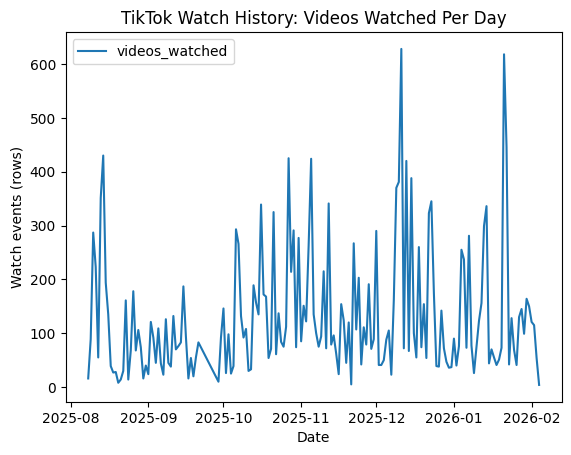

In [5]:
# Daily watch volume (line)
watch = data["Your Activity"]["Watch History"]["VideoList"]
df_watch = pd.DataFrame(watch)

df_watch["dt_ny"] = to_ny(df_watch["Date"])
daily_watch = df_watch.groupby(df_watch["dt_ny"].dt.date).size().reset_index(name="videos_watched")
daily_watch.rename(columns={"dt_ny":"Date"}, inplace=True)

daily_watch.head(10)

daily_watch.plot(x="Date", y="videos_watched", kind="line")
plt.title("TikTok Watch History: Videos Watched Per Day")
plt.xlabel("Date")
plt.ylabel("Watch events (rows)")
plt.show()

/tmp/ipykernel_2417/792451189.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_watch.assign(week_start=df_watch["dt_ny"].dt.to_period("W").dt.start_time)


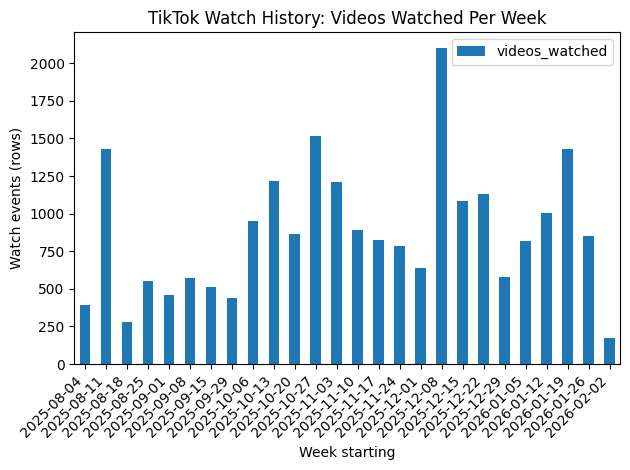

In [6]:
# Weekly Bars 

# Weekly totals bar chart (labels as dates only)
weekly_watch = (
    df_watch.assign(week_start=df_watch["dt_ny"].dt.to_period("W").dt.start_time)
    .groupby("week_start").size().reset_index(name="videos_watched")
)

# Convert to date-only labels
weekly_watch["week_start_date"] = weekly_watch["week_start"].dt.date.astype(str)

weekly_watch.plot(x="week_start_date", y="videos_watched", kind="bar")
plt.title("TikTok Watch History: Videos Watched Per Week")
plt.xlabel("Week starting")
plt.ylabel("Watch events (rows)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

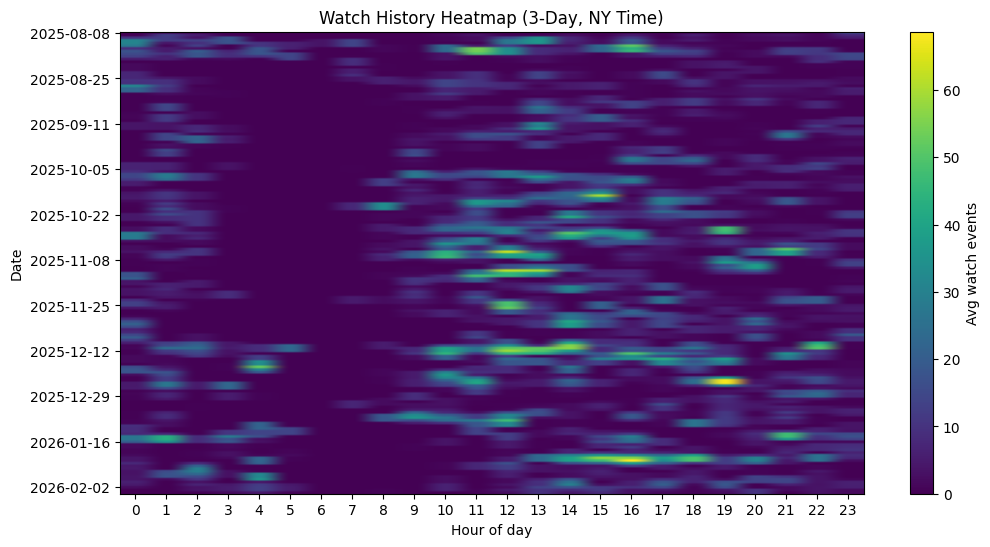

In [7]:
#Heatmap: day vs hour (watching)
#Shows: when you watch (time-of-day patterns + daily routine).
temp = df_watch.dropna(subset=["dt_ny"]).copy()
temp["date"] = temp["dt_ny"].dt.date
temp["hour"] = temp["dt_ny"].dt.hour

# Build the date x hour grid (counts)
pivot = temp.pivot_table(index="date", columns="hour", values="Date", aggfunc="count", fill_value=0)

# Smooth across days (3-day rolling average)
pivot_smooth = pivot.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.imshow(pivot_smooth.values, aspect="auto")
plt.title("Watch History Heatmap (3-Day, NY Time)")
plt.xlabel("Hour of day")
plt.ylabel("Date")
plt.xticks(range(24), range(24))
step = max(1, len(pivot_smooth.index)//10)
plt.yticks(range(0, len(pivot_smooth.index), step), [str(d) for d in pivot_smooth.index[::step]])
plt.colorbar(label="Avg watch events")
plt.show()

/tmp/ipykernel_2417/1851274311.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=order, showfliers=False)


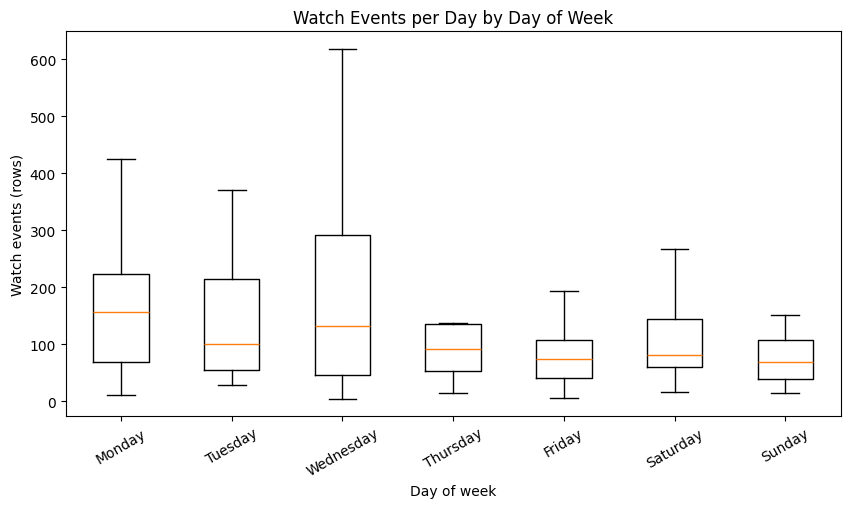

In [8]:
#Day-of-week boxplot (watch events/day)
daily_watch_dt = pd.to_datetime(daily_watch["Date"])
daily_watch["dow"] = daily_watch_dt.dt.day_name()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
groups = [daily_watch.loc[daily_watch["dow"]==d, "videos_watched"] for d in order]

plt.figure(figsize=(10,5))
plt.boxplot(groups, labels=order, showfliers=False)
plt.title("Watch Events per Day by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Watch events (rows)")
plt.xticks(rotation=30)
plt.show()

In [9]:
#Sessions per day + avg session length
temp = df_watch.dropna(subset=["dt_ny"]).sort_values("dt_ny").copy()
temp["prev"] = temp["dt_ny"].shift(1)
temp["gap_min"] = (temp["dt_ny"] - temp["prev"]).dt.total_seconds() / 60
temp["new_session"] = (temp["gap_min"].isna()) | (temp["gap_min"] > 30)
temp["session_id"] = temp["new_session"].cumsum()

sessions = (
    temp.groupby("session_id")
    .agg(start=("dt_ny","min"), end=("dt_ny","max"), events=("dt_ny","size"))
    .reset_index()
)
sessions["session_minutes"] = (sessions["end"] - sessions["start"]).dt.total_seconds() / 60
sessions["date"] = sessions["start"].dt.date

session_daily = sessions.groupby("date").agg(
    sessions_per_day=("session_id","nunique"),
    avg_session_minutes=("session_minutes","mean"),
    total_watch_events=("events","sum"),
).reset_index()

session_daily.head(10)

,date,sessions_per_day,avg_session_minutes,total_watch_events
0,2025-08-08,1,2.250000,16
1,2025-08-09,10,16.575000,89
2,2025-08-10,5,42.146667,287
3,2025-08-11,10,20.393333,223
4,2025-08-12,4,8.008333,55
5,2025-08-13,10,28.458333,351
6,2025-08-14,9,28.533333,430
7,2025-08-15,11,22.871212,194
8,2025-08-16,7,17.033333,135
9,2025-08-17,5,4.926667,39


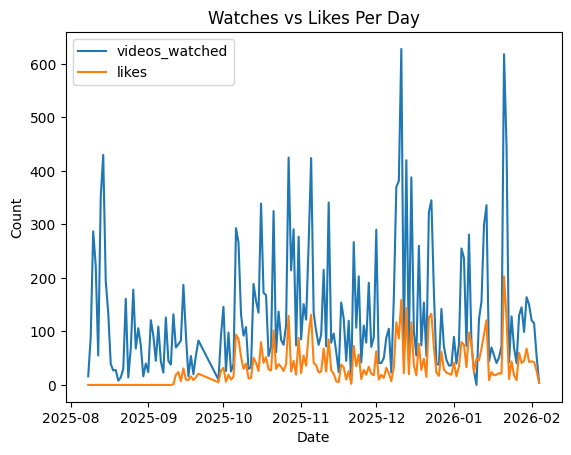

In [10]:
#Likes per day overlaid with watches per day
#This shows active engagement vs consumption.
likes = data["Likes and Favorites"]["Like List"]["ItemFavoriteList"]
df_like = pd.DataFrame(likes)

df_like["dt_ny"] = to_ny(df_like["date"])
daily_like = df_like.groupby(df_like["dt_ny"].dt.date).size().reset_index(name="likes")
daily_like.rename(columns={"dt_ny":"Date"}, inplace=True)

combined = pd.merge(daily_watch, daily_like, on="Date", how="outer").fillna(0)
combined.head(10)
combined.plot(x="Date", y=["videos_watched","likes"], kind="line")
plt.title("Watches vs Likes Per Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()

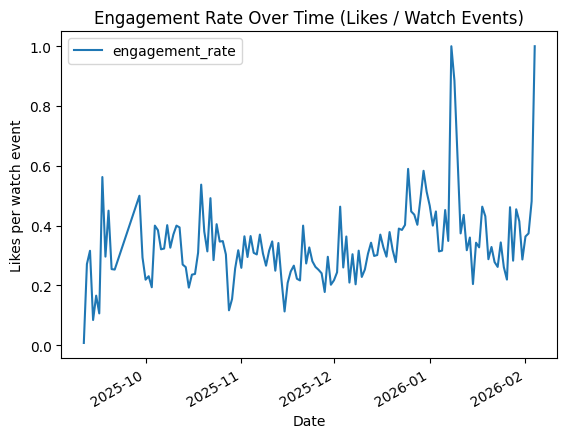

In [11]:
#Engagement rate over time (likes / watches)
#This shows whether you’re becoming more interactive over time.
import pandas as pd
import matplotlib.pyplot as plt


# Ensure Date is datetime
combined["Date"] = pd.to_datetime(combined["Date"], errors="coerce")

# Ensure numeric
combined["likes"] = pd.to_numeric(combined["likes"], errors="coerce")
combined["videos_watched"] = pd.to_numeric(combined["videos_watched"], errors="coerce")

# Convert cutoff (like start date) to datetime
cutoff = pd.to_datetime(daily_like["Date"].min())

# Filter to dates where likes data exists (no forced zeros)
plot_df = combined[combined["Date"] >= cutoff].copy()

# Engagement rate
plot_df["engagement_rate"] = plot_df["likes"] / plot_df["videos_watched"].replace(0, pd.NA)

plot_df = plot_df.dropna(subset=["engagement_rate"]).sort_values("Date")

plot_df.plot(x="Date", y="engagement_rate", kind="line")
plt.title("Engagement Rate Over Time (Likes / Watch Events)")
plt.xlabel("Date")
plt.ylabel("Likes per watch event")
plt.show()

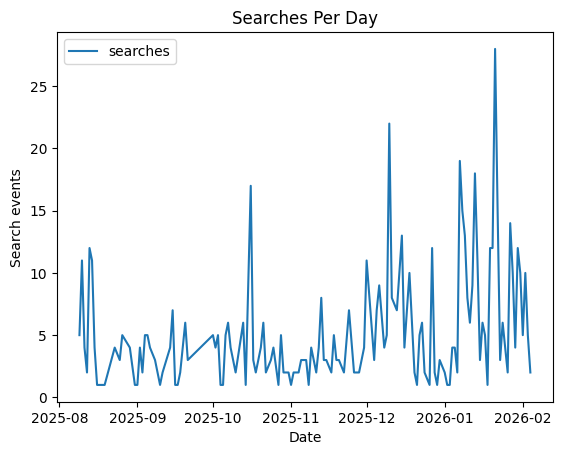

In [12]:
searches = data["Your Activity"]["Searches"]["SearchList"]
df_search = pd.DataFrame(searches)

# TikTok exports sometimes use "Date" and "SearchTerm" (or similar).
df_search["dt_ny"] = to_ny(df_search["Date"])

daily_search = df_search.groupby(df_search["dt_ny"].dt.date).size().reset_index(name="searches")
daily_search.rename(columns={"dt_ny":"Date"}, inplace=True)
daily_search.head(10)

daily_search.plot(x="Date", y="searches", kind="line")
plt.title("Searches Per Day")
plt.xlabel("Date")
plt.ylabel("Search events")
plt.show()

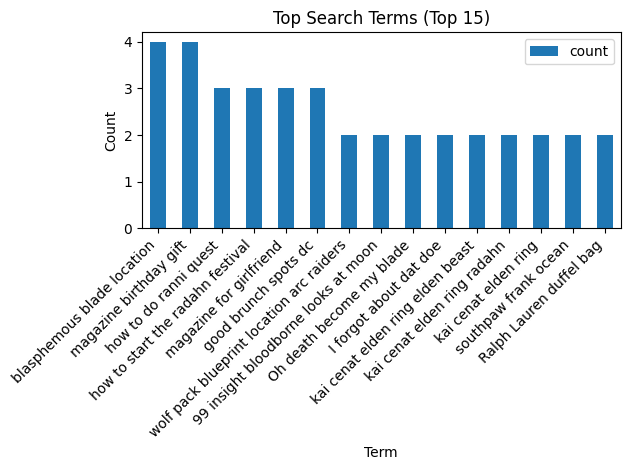

In [13]:
# Try common field names
term_col = None
for c in df_search.columns:
    if "search" in c.lower() and c.lower() != "date":
        term_col = c
        break

term_col

top_terms = df_search[term_col].value_counts().head(15).reset_index()
top_terms.columns = ["term", "count"]

top_terms.plot(x="term", y="count", kind="bar")
plt.title("Top Search Terms (Top 15)")
plt.xlabel("Term")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

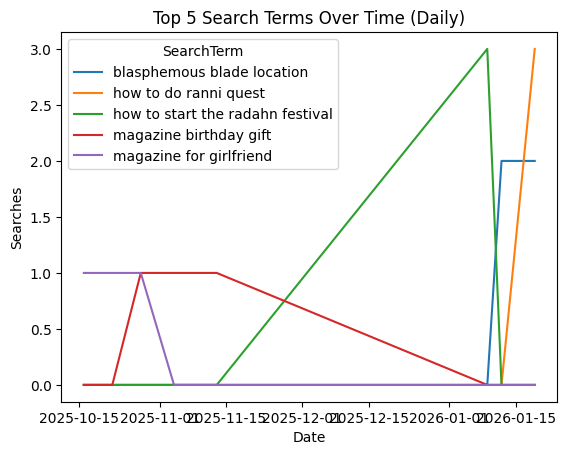

In [ ]:
#To messy
top5 = df_search[term_col].value_counts().head(5).index.tolist()
temp = df_search[df_search[term_col].isin(top5)].copy()
temp["date"] = temp["dt_ny"].dt.date

trend = temp.groupby(["date", term_col]).size().unstack(fill_value=0).reset_index()
trend.head(10)
trend.plot(x="date", kind="line")
plt.title("Top 5 Search Terms Over Time (Daily)")
plt.xlabel("Date")
plt.ylabel("Searches")
plt.show()

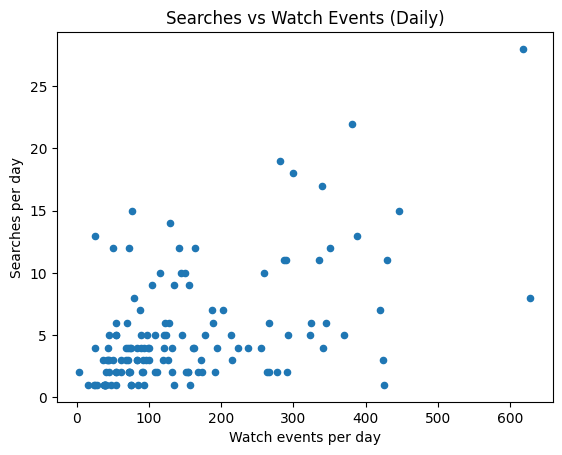

In [15]:
combo2 = pd.merge(daily_watch, daily_search, on="Date", how="inner")
combo2.plot(x="videos_watched", y="searches", kind="scatter")
plt.title("Searches vs Watch Events (Daily)")
plt.xlabel("Watch events per day")
plt.ylabel("Searches per day")
plt.show()

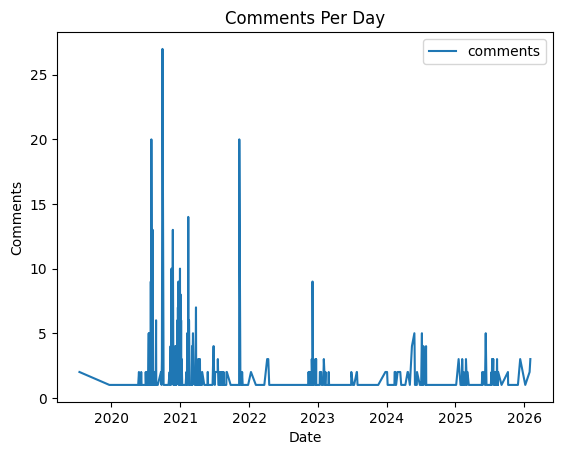

In [ ]:

#Comments per day

comments = data["Comment"]["Comments"]["CommentsList"]
df_com = pd.DataFrame(comments)

df_com["dt_ny"] = to_ny(df_com["date"])
daily_com = df_com.groupby(df_com["dt_ny"].dt.date).size().reset_index(name="comments")
daily_com.rename(columns={"dt_ny":"Date"}, inplace=True)

daily_com.plot(x="Date", y="comments", kind="line")
plt.title("Comments Per Day")
plt.xlabel("Date")
plt.ylabel("Comments")
plt.show()

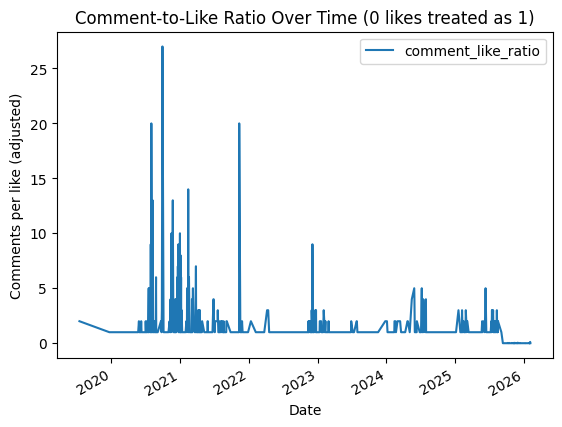

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

daily_like["Date"] = pd.to_datetime(daily_like["Date"], errors="coerce")
daily_com["Date"]  = pd.to_datetime(daily_com["Date"], errors="coerce")

combo3 = pd.merge(daily_like, daily_com, on="Date", how="outer").fillna(0)

combo3["likes"] = pd.to_numeric(combo3["likes"], errors="coerce").fillna(0)
combo3["comments"] = pd.to_numeric(combo3["comments"], errors="coerce").fillna(0)

# Replace 0 likes with 1 so we can compute a finite ratio
combo3["comment_like_ratio"] = combo3["comments"] / combo3["likes"].replace(0, 1)

combo3 = combo3.sort_values("Date")

combo3.plot(x="Date", y="comment_like_ratio", kind="line")
plt.title("Comment-to-Like Ratio Over Time (0 likes treated as 1)")
plt.xlabel("Date")
plt.ylabel("Comments per like (adjusted)")
plt.show()

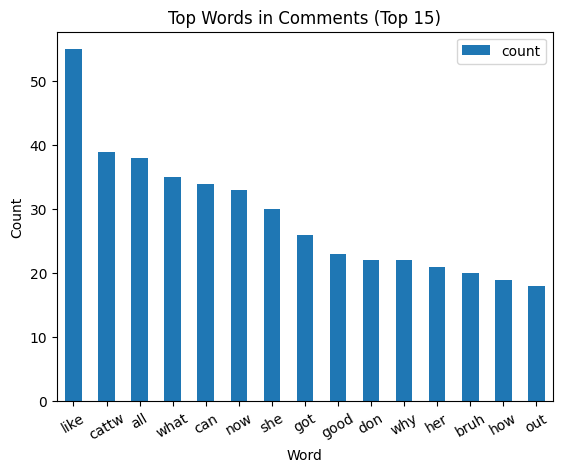

In [21]:
import re
from collections import Counter

text_col = None
for c in df_com.columns:
    if "comment" in c.lower() or "content" in c.lower() or "text" in c.lower():
        text_col = c
        break

text_col

def tokenize(s):
    s = str(s).lower()
    s = re.sub(r"http\S+", "", s)
    words = re.findall(r"[a-z']+", s)
    stop = set(["the","and","for","that","with","this","you","your","was","are","but","not","have","just","its","i","im","to","of","in","it","on","a","is"])
    return [w for w in words if w not in stop and len(w) > 2]

counter = Counter()
for t in df_com[text_col].dropna().head(5000):
    counter.update(tokenize(t))

top_words = pd.DataFrame(counter.most_common(15), columns=["word","count"])
top_words.plot(x="word", y="count", kind="bar")
plt.title("Top Words in Comments (Top 15)")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

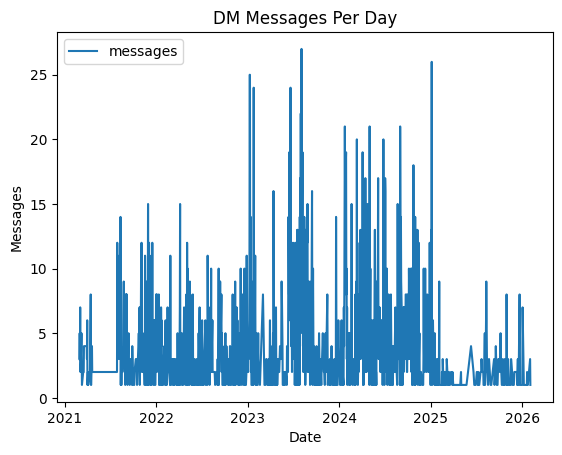

/tmp/ipykernel_2417/2912843590.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_dm.assign(week=df_dm["dt_ny"].dt.to_period("W").dt.start_time)


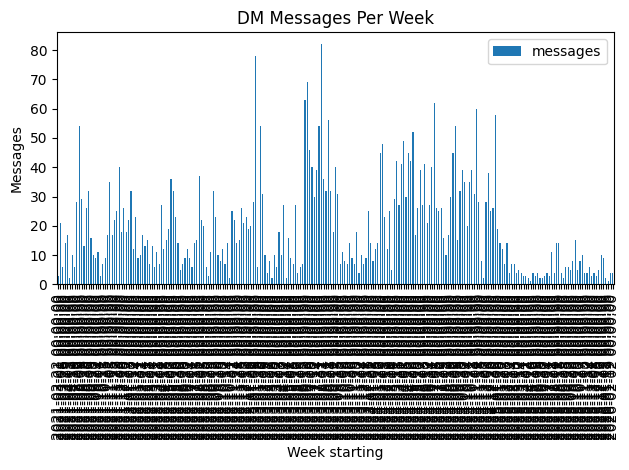

In [22]:
# Aggregate all DM chats into one DataFrame
chats = data["Direct Message"]["Direct Messages"]["ChatHistory"]
all_msgs = []
for conv_name, msgs in chats.items():
    if isinstance(msgs, list):
        for m in msgs:
            m2 = dict(m)
            m2["conversation"] = conv_name
            all_msgs.append(m2)

df_dm = pd.DataFrame(all_msgs)
df_dm["dt_ny"] = to_ny(df_dm["Date"])

daily_dm = df_dm.groupby(df_dm["dt_ny"].dt.date).size().reset_index(name="messages")
daily_dm.rename(columns={"dt_ny":"Date"}, inplace=True)

daily_dm.plot(x="Date", y="messages", kind="line")
plt.title("DM Messages Per Day")
plt.xlabel("Date")
plt.ylabel("Messages")
plt.show()
weekly_dm = (
    df_dm.assign(week=df_dm["dt_ny"].dt.to_period("W").dt.start_time)
    .groupby("week").size().reset_index(name="messages")
)
weekly_dm.plot(x="week", y="messages", kind="bar")
plt.title("DM Messages Per Week")
plt.xlabel("Week starting")
plt.ylabel("Messages")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2417/2913051793.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=df_dm["dt_ny"].dt.to_period("M").dt.to_timestamp())


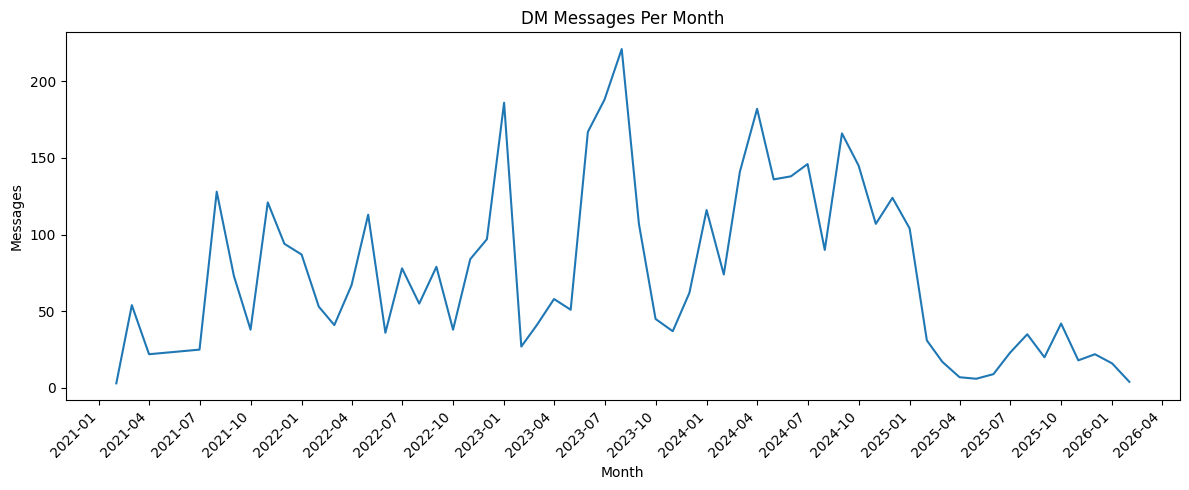

In [23]:
import matplotlib.dates as mdates

monthly_dm = (
    df_dm.dropna(subset=["dt_ny"])
    .assign(month=df_dm["dt_ny"].dt.to_period("M").dt.to_timestamp())
    .groupby("month").size().reset_index(name="messages")
).sort_values("month")

plt.figure(figsize=(12,5))
plt.plot(monthly_dm["month"], monthly_dm["messages"])
plt.title("DM Messages Per Month")
plt.xlabel("Month")
plt.ylabel("Messages")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2417/579489652.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(week_start=df_dm["dt_ny"].dt.to_period("W").dt.start_time)


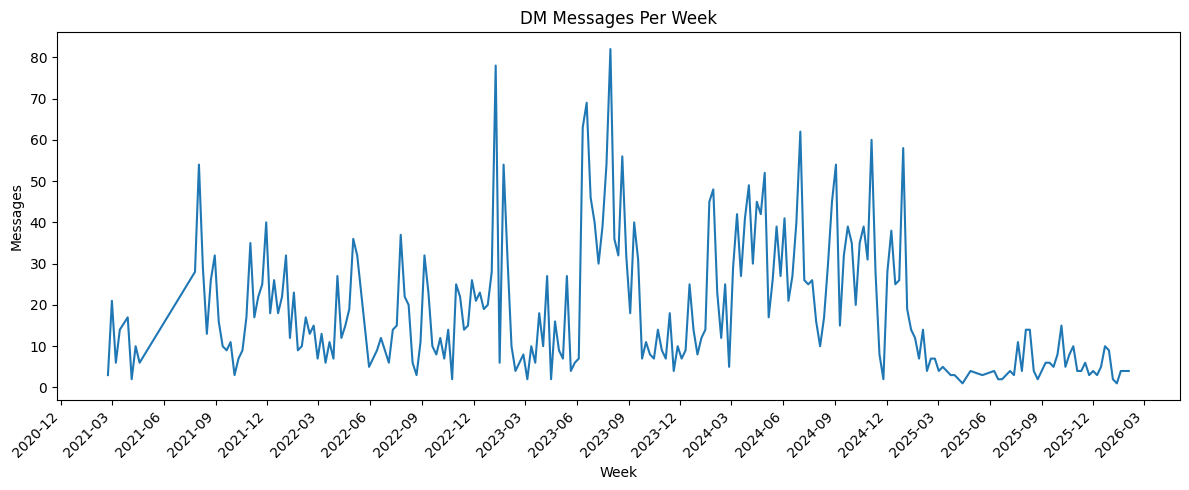

In [24]:
import matplotlib.dates as mdates

weekly_dm = (
    df_dm.dropna(subset=["dt_ny"])
    .assign(week_start=df_dm["dt_ny"].dt.to_period("W").dt.start_time)
    .groupby("week_start").size().reset_index(name="messages")
)

weekly_dm = weekly_dm.sort_values("week_start")

plt.figure(figsize=(12,5))
plt.plot(weekly_dm["week_start"], weekly_dm["messages"])
plt.title("DM Messages Per Week")
plt.xlabel("Week")
plt.ylabel("Messages")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))      # label every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

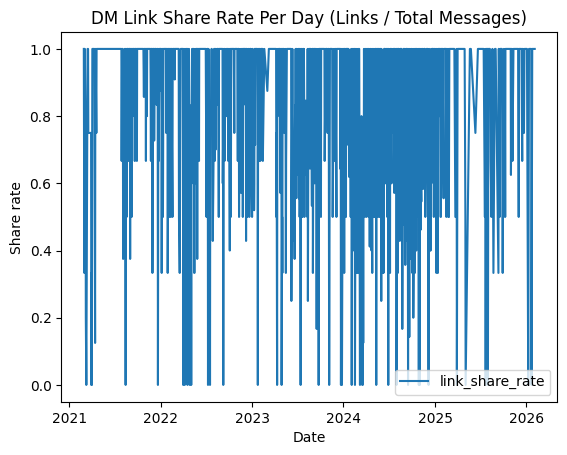

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure dt_ny exists
df_dm["dt_ny"] = to_ny(df_dm["Date"])

# Mark link messages
df_dm["is_link"] = df_dm["Content"].astype(str).str.contains("http", na=False)

# Daily link share rate
daily_link_rate = (
    df_dm.groupby(df_dm["dt_ny"].dt.date)
    .agg(total_msgs=("is_link", "size"), link_msgs=("is_link", "sum"))
    .reset_index()
)

daily_link_rate.rename(columns={"dt_ny": "Date"}, inplace=True)  # this works because groupby key becomes dt_ny column name
daily_link_rate["link_share_rate"] = daily_link_rate["link_msgs"] / daily_link_rate["total_msgs"]

# Plot (use Date, not dt_ny)
daily_link_rate.plot(x="Date", y="link_share_rate", kind="line")
plt.title("DM Link Share Rate Per Day (Links / Total Messages)")
plt.xlabel("Date")
plt.ylabel("Share rate")
plt.show()